# 02 - Tamaño de muestra y poder estadístico

Este notebook responde una pregunta que, en un caso real, hay que hacerse
**antes** de lanzar un experimento: ¿cuántos datos necesito para poder confiar
en el resultado? Acá usamos los datos ya generados solo para tener números
realistas con los que ilustrar el cálculo -- en un proyecto real, este
análisis se haría con una estimación previa de la variabilidad (de un período
anterior sin el experimento) y **antes** de arrancar, no después.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

plt.rcParams["figure.figsize"] = (10, 5)

metricas = pd.read_csv("../data/processed/metricas_diarias.csv", parse_dates=["fecha"])
metricas.head()

,fecha,sucursal,variante,dia_semana,semana,visitantes,compras,conversion_dia,ticket_promedio_dia
0,2026-03-02,Centro,B,Lunes,1,157,28,0.178344,43764.923571
1,2026-03-02,Norte,A,Lunes,1,110,23,0.209091,46633.181304
2,2026-03-02,Oeste,B,Lunes,1,129,11,0.085271,37268.610000
3,2026-03-02,Sur,A,Lunes,1,94,12,0.127660,50657.785000
4,2026-03-03,Centro,A,Martes,1,145,25,0.172414,40908.787200


## 1. Dos tipos de error, y qué es el "poder" de un test

Cuando comparamos la variante A contra la B, hay dos formas de
equivocarse:

- **Error de tipo I (falso positivo):** concluir que el cartel nuevo funciona
  mejor cuando en realidad no hay diferencia real. La probabilidad de cometer
  este error se llama **alpha** (α) -- normalmente se fija en 0.05 (5%) *antes*
  de mirar los datos.
- **Error de tipo II (falso negativo):** concluir que no hay diferencia cuando
  en realidad el cartel nuevo sí funciona mejor. La probabilidad de este error
  se llama **beta** (β).

El **poder estadístico** de un test es `1 - β`: la probabilidad de detectar un
efecto real, si ese efecto realmente existe. Un poder del 80% (el estándar más
usado) significa: "si el efecto real es del tamaño que estoy asumiendo, tengo
80% de probabilidad de que el experimento lo detecte como estadísticamente
significativo".

**Analogía:** pensalo como un control de calidad que busca piezas defectuosas.
Alpha es la probabilidad de rechazar una pieza que en realidad está bien
(falsa alarma). Beta es la probabilidad de dejar pasar una pieza que en
realidad está rota (falla no detectada). El tamaño de muestra es, en el fondo,
"cuántas piezas tengo que inspeccionar para confiar en el resultado del
control".

**¿Por qué importa calcular esto antes de correr el experimento?** Si se corre
un experimento con muy pocos datos, puede que exista una diferencia real entre
A y B pero que el experimento no tenga poder suficiente para detectarla -- y
se concluya erróneamente "no hay diferencia", cuando en realidad lo que faltó
fue tamaño de muestra.

## 2. El enfoque ingenuo: tamaño de muestra a nivel visitante

La fórmula clásica de tamaño de muestra para comparar dos proporciones
(por ejemplo, dos tasas de conversión) asume que cada observación es
**independiente** de las demás. Si tratáramos cada visitante como una
observación independiente, así se calcularía cuántos visitantes por variante
harían falta para detectar una diferencia de conversión de cierto tamaño.

In [2]:
conversion_base_A = metricas.loc[metricas["variante"] == "A", "compras"].sum() / metricas.loc[metricas["variante"] == "A", "visitantes"].sum()
mde_conversion = 0.03  # efecto mínimo que nos interesaría detectar: +3 puntos porcentuales

effect_size = proportion_effectsize(conversion_base_A, conversion_base_A + mde_conversion)

analisis_proporcion = NormalIndPower()
n_visitantes_por_variante = analisis_proporcion.solve_power(
    effect_size=effect_size, alpha=0.05, power=0.80, ratio=1.0
)

print(f"Conversión base (variante A): {conversion_base_A:.3f}")
print(f"MDE asumido: +{mde_conversion:.2f} (puntos porcentuales)")
print(f"Visitantes necesarios por variante (enfoque ingenuo): {n_visitantes_por_variante:,.0f}")

Conversión base (variante A): 0.180
MDE asumido: +0.03 (puntos porcentuales)
Visitantes necesarios por variante (enfoque ingenuo): 2,731


Con el tráfico real de este experimento (más de 12.000 visitantes por
variante), este número ingenuo se alcanzaría en muy pocos días. **Pero este
cálculo tiene un problema serio -- ver la sección 3.**

## 3. Por qué el enfoque ingenuo es engañoso acá

La fórmula de la sección 2 asume que cada visitante es una observación
independiente de las demás. Pero en este experimento **el cartel se asigna por
día, no por visitante**: todos los visitantes que entran el mismo día a la
misma sucursal ven la misma variante y comparten el mismo contexto de ese día
(por ejemplo, si ese lunes hubo una promoción cruzada, un evento en la zona, o
simplemente un día con más apuro de compra). Esto hace que los visitantes de
un mismo día estén **correlacionados entre sí** -- no aportan tanta
información nueva, cada uno, como si fueran completamente independientes.

Tratar a cada visitante como independiente cuando en realidad la asignación
fue por día es el mismo error de **pseudoreplicación** que discutimos en el
notebook 01: hace que el resultado *parezca* mucho más confiable de lo que
realmente es. La consecuencia práctica es que el número de visitantes
"necesarios" calculado en la sección 2 subestima muchísimo el esfuerzo real
del experimento -- la verdadera unidad de la que depende la confianza del
resultado es **el día**, no el visitante.

## 4. El enfoque correcto: tamaño de muestra a nivel día

Como el notebook 03 va a comparar métricas *agregadas por día* entre
variantes (un t-test de dos muestras sobre la conversión diaria y sobre el
ticket promedio diario), el cálculo de tamaño de muestra tiene que hacerse en
esa misma unidad: ¿cuántos **días** por variante hacen falta?

Para esto se necesita la variabilidad día a día de cada métrica (que ya
podemos estimar con los datos) y el tamaño de efecto expresado en esa escala
(Cohen's d: la diferencia esperada dividida por el desvío estándar entre
días).

In [3]:
conv_A = metricas.loc[metricas["variante"] == "A", "conversion_dia"]
conv_B = metricas.loc[metricas["variante"] == "B", "conversion_dia"]

sd_conversion_dia = conv_A.std()  # variabilidad día a día dentro de la variante A
cohens_d_conversion = mde_conversion / sd_conversion_dia

analisis_dia = TTestIndPower()
n_dias_conversion = analisis_dia.solve_power(
    effect_size=cohens_d_conversion, alpha=0.05, power=0.80, ratio=1.0
)

print(f"Desvío estándar de la conversión diaria (variante A): {sd_conversion_dia:.4f}")
print(f"Cohen's d equivalente al MDE de +{mde_conversion:.2f}: {cohens_d_conversion:.3f}")
print(f"Días necesarios por variante (enfoque correcto): {n_dias_conversion:.1f}")

Desvío estándar de la conversión diaria (variante A): 0.0568
Cohen's d equivalente al MDE de +0.03: 0.528
Días necesarios por variante (enfoque correcto): 57.2


In [4]:
ticket_A = metricas.loc[metricas["variante"] == "A", "ticket_promedio_dia"].dropna()
ticket_B = metricas.loc[metricas["variante"] == "B", "ticket_promedio_dia"].dropna()

mde_ticket_relativo = 0.05  # nos interesaría detectar al menos +5% de ticket promedio
mde_ticket_absoluto = ticket_A.mean() * mde_ticket_relativo
sd_ticket_dia = ticket_A.std()
cohens_d_ticket = mde_ticket_absoluto / sd_ticket_dia

n_dias_ticket = analisis_dia.solve_power(
    effect_size=cohens_d_ticket, alpha=0.05, power=0.80, ratio=1.0
)

print(f"Ticket promedio diario base (variante A): ${ticket_A.mean():,.0f}")
print(f"MDE asumido: +{mde_ticket_relativo:.0%} (${mde_ticket_absoluto:,.0f})")
print(f"Desvío estándar del ticket diario (variante A): ${sd_ticket_dia:,.0f}")
print(f"Días necesarios por variante para detectar este MDE en ticket: {n_dias_ticket:.1f}")

Ticket promedio diario base (variante A): $44,553
MDE asumido: +5% ($2,228)
Desvío estándar del ticket diario (variante A): $5,479
Días necesarios por variante para detectar este MDE en ticket: 95.9


**La diferencia clave:** el cálculo ingenuo (a nivel visitante) diría que
alcanzan unos pocos días, porque cuenta miles de visitantes como si fueran
independientes. El cálculo correcto (a nivel día) pide muchos más días, porque
la unidad real de información es el día, no el visitante. Esa brecha es la
consecuencia directa de identificar bien la unidad de randomización -- por eso
el diseño (notebook 01) y el tamaño de muestra se piensan juntos.

## 5. Curva de sensibilidad: cuánto más grande el efecto, menos días hacen falta

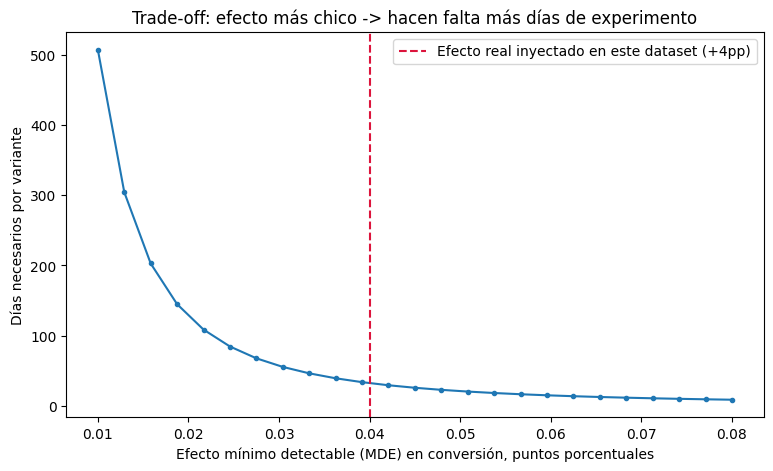

In [5]:
mdes_conversion = np.linspace(0.01, 0.08, 25)
dias_necesarios = [
    analisis_dia.solve_power(effect_size=mde / sd_conversion_dia, alpha=0.05, power=0.80, ratio=1.0)
    for mde in mdes_conversion
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mdes_conversion, dias_necesarios, marker="o", markersize=3)
ax.axvline(0.04, color="crimson", linestyle="--", label="Efecto real inyectado en este dataset (+4pp)")
ax.set_xlabel("Efecto mínimo detectable (MDE) en conversión, puntos porcentuales")
ax.set_ylabel("Días necesarios por variante")
ax.set_title("Trade-off: efecto más chico -> hacen falta más días de experimento")
ax.legend()
plt.show()

**Lo que muestra la curva:** la cantidad de días necesarios crece muy rápido a
medida que el efecto a detectar se achica (la relación va como ~1/MDE²). Por eso
conviene diseñar el experimento para detectar el efecto mínimo que *cambiaría una
decisión de negocio*, no el más chico imaginable: perseguir 0,1 pp de mejora
puede requerir un experimento carísimo e irrelevante.

## 6. Chequeo retrospectivo: ¿el experimento que realmente se corrió tenía poder suficiente?

In [6]:
dias_por_variante_real = metricas.groupby("variante")["fecha"].nunique()
print("Días-sucursal por variante en el experimento real:")
print(dias_por_variante_real)

n_dias_real = metricas.loc[metricas["variante"] == "A"].shape[0]  # incluye las 4 sucursales

mde_minimo_detectable = analisis_dia.solve_power(
    nobs1=n_dias_real, alpha=0.05, power=0.80, ratio=1.0
) * sd_conversion_dia

print(f"\nObservaciones día-sucursal por variante realmente disponibles: {n_dias_real}")
print(f"MDE mínimo detectable con ese tamaño de muestra (poder 80%): {mde_minimo_detectable:.4f} ({mde_minimo_detectable*100:.2f} puntos porcentuales)")
print(f"Efecto real inyectado en el dataset: 0.04 (4 puntos porcentuales)")

Días-sucursal por variante en el experimento real:
variante
A    56
B    55
Name: fecha, dtype: int64

Observaciones día-sucursal por variante realmente disponibles: 120
MDE mínimo detectable con ese tamaño de muestra (poder 80%): 0.0206 (2.06 puntos porcentuales)
Efecto real inyectado en el dataset: 0.04 (4 puntos porcentuales)


**Poder del experimento real:** con los días efectivamente disponibles (120
observaciones día-sucursal por variante), el MDE mínimo detectable con poder 80%
queda por debajo de los 4 pp de efecto inyectado. Es decir, el experimento tal
como se diseñó tenía poder de sobra para detectar un efecto de esa magnitud --
lo que se confirma en el notebook 03.

## Conclusiones

- El tamaño de muestra "ingenuo" (a nivel visitante) subestima gravemente el
  esfuerzo real, porque ignora que la randomización fue por día.
- El cálculo correcto (a nivel día) da un número de días mucho más alto y
  realista para el diseño.
- Los días que efectivamente se corrieron (60 por sucursal, 30 con cada
  variante) alcanzaban para detectar el efecto inyectado -- se confirma en el
  notebook 03.

**Próximo notebook (03):** correr el test de hipótesis sobre las métricas
diarias, calcular p-valor e IC, y llegar a una recomendación de negocio.